In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt

In [2]:
# galaxy map
gal = hp.read_map("../galaxy_samples/1_delta.fits", field=0)
nside_gal = hp.get_nside(gal)

mask = hp.read_map("../masks/mask.fits")

In [3]:
b = nmt.NmtBin.from_nside_linear(nside_gal, 100)
gal_field = nmt.NmtField(mask, [gal])

cl_gal = nmt.compute_full_master(gal_field, gal_field, b)

In [4]:
alm_gal = hp.map2alm(gal, lmax=3000)
gal_map = hp.alm2map(alm_gal, lmax=3000, nside=nside_gal)

# hp.mollview(gal_map, title="galaxy map")
# plt.show()

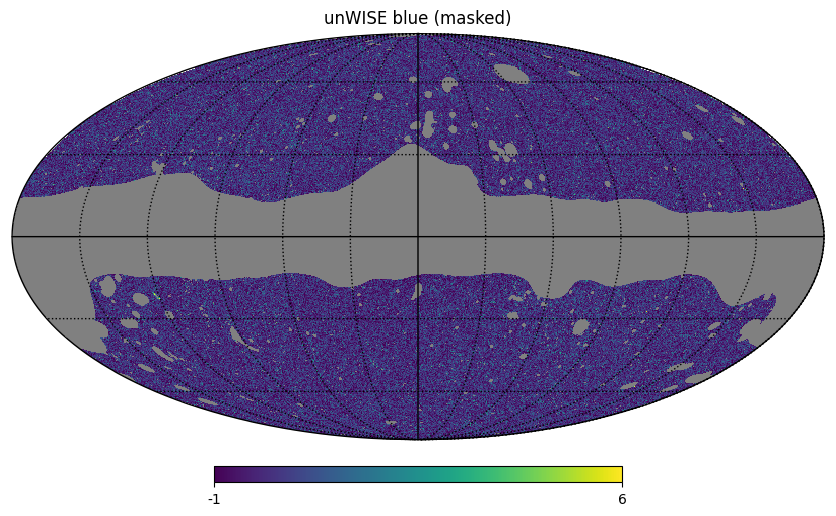

In [7]:
cmap = plt.cm.viridis.copy()
cmap.set_bad("gray")
cmap.set_under("white")

gal_masked = gal * mask
gal_masked = np.where(mask > 0, gal, hp.UNSEEN)
hp.mollview(
    gal_masked,
    title="unWISE blue (masked)",
    cmap = cmap, min=-1, max=6)
hp.graticule()

# hp.mollview(gal_masked, coord=['G','C'])
plt.show()

In [ ]:
# ell_arr = b.get_effective_ells()
# cl_gg = 1e5 * cl_gal[0]

# fig, ax = plt.subplots(figsize=(5.2, 4.0))

# fsky = np.mean(mask**2)

# delta_ell = 200  # or whatever bin width you used

# errors = np.sqrt(
#     2 / ((2 * ell_arr + 1) * delta_ell * fsky)
# ) * cl_gg

# ax.errorbar(
#     ell_arr,
#     cl_gg,
#     yerr=1e5 * errors,
#     fmt='o',
#     # color=colors[label],
#     markersize=3,
#     capsize=3,
#     elinewidth=1,
#     # label=label
# )

# ax.set_xlim(100, 1000)
# ax.set_ylim(0, 0.18)

# ax.set_xlabel(r'$\ell$', fontsize=16)
# ax.set_ylabel(r'$10^5 \times C_\ell^{gg}$', fontsize=16)

# ax.grid(True, alpha=0.25, linestyle='--')
# ax.legend(loc='upper right', fontsize=10)

# plt.tight_layout()
# plt.show()

In [9]:
field = nmt.NmtField(mask, [gal_map])

w = nmt.NmtWorkspace()
w.compute_coupling_matrix(field, field, b)

cl = nmt.compute_full_master(field, field, b)[0]

In [10]:
cw = nmt.NmtCovarianceWorkspace()
cw.compute_coupling_coefficients(field, field, field, field)

In [11]:
ell_arr = b.get_effective_ells()
ells_full = np.arange(3 * nside_gal)

cl_full = np.interp(
    ells_full,
    ell_arr,
    cl,
    left=cl[0],
    right=cl[-1]
)

cl_full = cl_full.reshape(1, -1)

In [12]:
cov = nmt.gaussian_covariance(
    cw,
    0, 0, 0, 0,
    cl_full,
    cl_full,
    cl_full,
    cl_full,
    w
)

In [13]:
nbins = len(ell_arr)

cov = cov.reshape([nbins, 1, nbins, 1])[:, 0, :, 0]
errors = np.sqrt(np.diag(cov))

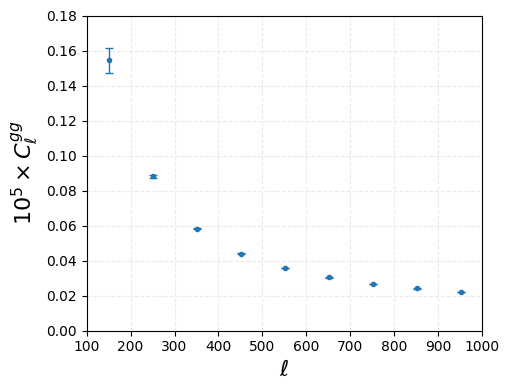

In [15]:
ell_arr = b.get_effective_ells()
cl_gg = 1e5 * cl_gal[0]

plt.figure(figsize=(5.2, 4.0))

# fsky = np.mean(mask**2)

# delta_ell = 200  # or whatever bin width you used

# errors = np.sqrt(
#     2 / ((2 * ell_arr + 1) * delta_ell * fsky)
# ) * cl_gg

plt.errorbar(
    ell_arr,
    1e5 * cl,
    yerr=1e5 * errors,
    fmt='o',
    # color=colors[label],
    markersize=3,
    capsize=3,
    elinewidth=1,
    # label=label
);

plt.xlim(100, 1000)
plt.ylim(0, 0.18)

plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$10^5 \times C_\ell^{gg}$', fontsize=16)

plt.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()